El objetivo de este notebook es generar predicciones para la variable 'z' de redshift utilizando el resto de 

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().resolve().parent))
from preprocess_vae import load_features

In [20]:
df = load_features()

Filtros de catálogo:
  inicial            : 29575
  maskbits==0        : 27757
  flujo>0 (griz)     : 26166
  profundidad (mag)  : 21340
  SNR>=3 (griz)      : 21287


In [21]:
df.columns

Index(['desi_id', 'mean_fiber_ra', 'mean_fiber_dec', 'z', 'zerr', 'ra', 'dec',
       'type', 'shape_r', 'shape_e1', 'shape_e2', 'sersic', 'ebv', 'brickid',
       'dchisq_psf', 'dchisq_rex', 'dchisq_exp', 'dchisq_dev', 'dchisq_ser',
       'id', 'flux_g', 'flux_r', 'flux_i', 'flux_z', 'flux_w1', 'flux_w2',
       'flux_w3', 'flux_w4', 'flux_ivar_g', 'flux_ivar_r', 'flux_ivar_i',
       'flux_ivar_z', 'flux_ivar_w1', 'flux_ivar_w2', 'flux_ivar_w3',
       'flux_ivar_w4', 'mw_transmission_i', 'fitbits', 'mw_transmission_w1',
       'brickname', 'mw_transmission_z', 'mw_transmission_g', 'maskbits',
       'mw_transmission_w2', 'mw_transmission_w3', 'objid',
       'mw_transmission_w4', 'mw_transmission_r', 'mag_g_corr', 'mag_r_corr',
       'mag_i_corr', 'mag_z_corr', 'SNR_g', 'SNR_r', 'SNR_i', 'SNR_z'],
      dtype='str')

Las features a utilizar serán las que dan información sobre la forma, tamaño y color de las galaxias, así como las coordenadas de las mismas.

In [22]:
df['mag_w1_corr'] = df['flux_w1']/df['mw_transmission_w1']
df['mag_w2_corr'] = df['flux_w2']/df['mw_transmission_w2']
df['mag_w3_corr'] = df['flux_w3']/df['mw_transmission_w3']
df['mag_w4_corr'] = df['flux_w4']/df['mw_transmission_w4']

In [23]:

df = df[['type', 'shape_r', 'shape_e1', 'shape_e2', 'sersic', "mag_g_corr", "mag_r_corr", "mag_i_corr", "mag_z_corr", "mag_w1_corr", "mag_w2_corr", "mag_w3_corr", "mag_w4_corr",'z']]
df.dropna(inplace=True)
X = df.drop(columns=['z'])
y = df['z']

In [24]:
y.min()

np.float64(-1.931031910083113e-05)

In [25]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [26]:
def compute_photoz_metrics(z_true, z_pred, threshold=0.05, label=None):
    """Métricas estándar de photo-z: residuos normalizados, sigma_MAD y tasa de outliers catastróficos."""
    z_true = np.asarray(z_true, dtype=float)
    z_pred = np.asarray(z_pred, dtype=float)

    # Residuo normalizado: Δz = (z_pred - z_true) / (1 + z_true)
    delta_z = (z_pred - z_true) / (1 + z_true)

    bias = delta_z.mean()
    std = delta_z.std()
    sigma_mad = 1.4826 * np.median(np.abs(delta_z - np.median(delta_z)))
    eta = (np.abs(delta_z) > threshold).mean() * 100

    if label:
        print(f"--- Métricas photo-z: {label} ---")
    print(f"<Δz> (bias)              = {bias:.5f}")
    print(f"std(Δz)                  = {std:.5f}")
    print(f"σ_MAD                    = {sigma_mad:.5f}")
    print(f"η [%] (|Δz| > {threshold})     = {eta:.3f}")

    return {"delta_z": delta_z, "bias": bias, "std": std, "sigma_mad": sigma_mad, "eta": eta}


def plot_specz_vs_photoz(z_true, z_pred, threshold=0.05, title=None, ax=None):
    """Scatter z_spec vs z_phot con línea 1:1 (punteada) y límites de error catastrófico (rojo, lw=5)."""
    z_true = np.asarray(z_true, dtype=float)
    z_pred = np.asarray(z_pred, dtype=float)

    if ax is None:
        _, ax = plt.subplots(figsize=(8, 8))

    ax.scatter(z_true, z_pred, alpha=0.4, s=4)

    lo = min(z_true.min(), z_pred.min())
    hi = max(z_true.max(), z_pred.max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=2, label="1:1")

    z_line = np.linspace(lo, hi, 200)
    ax.plot(z_line, z_line + threshold * (1 + z_line), color="red", lw=3,
            label=f"Límite error catastrófico (|Δz| > {threshold})")
    ax.plot(z_line, z_line - threshold * (1 + z_line), color="red", lw=3)

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel("Redshift espectroscópico")
    ax.set_ylabel("Redshift fotométrico predicho")
    if title:
        ax.set_title(title)
    ax.legend(loc="upper left", fontsize=8)

    return ax

In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Clasificación por bins de redshift
n_bins = 18
bins = np.linspace(y.min(), y.max(), n_bins + 1)
y_cls = pd.cut(y, bins=bins, include_lowest=True, labels=False)

# Las clases están fuertemente desbalanceadas (los bins de bajo z concentran la
# mayoría de las galaxias), por lo que hay que compensarlo en el entrenamiento y en las métricas.
print("Distribución de clases (bins de z):")
print(y_cls.value_counts().sort_index())

# Split estratificado por clase de redshift
X_train, X_test, y_train, y_test, z_train, z_test = train_test_split(
    X, y_cls, y,
    test_size=0.2,
    random_state=42,
    stratify=y_cls
)
X_test_clf, y_test_clf = X_test, y_test  # se reutilizan más abajo para interpretabilidad

numeric_features = [c for c in X.columns if c != "type"]
categorical_features = ["type"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), categorical_features),
    ]
)

clf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", HistGradientBoostingClassifier(
        random_state=42,
        learning_rate=0.05,
        max_depth=6,
        max_iter=300,
        class_weight="balanced",  # compensa el desbalance entre bins de redshift
    ))
])

clf.fit(X_train, y_train)

# Predicción de clase
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)

# Reconstrucción de z_phot a partir de probabilidades de clase
class_centers = np.array([(bins[i] + bins[i + 1]) / 2 for i in range(len(bins) - 1)])
z_phot = y_proba @ class_centers

# Métricas de clasificación (balanced_accuracy y macro-F1 son robustas al desbalance de clases)
acc = accuracy_score(y_test, y_pred)
bacc = balanced_accuracy_score(y_test, y_pred)
f1m = f1_score(y_test, y_pred, average="macro")

print("Accuracy:", acc)
print("Balanced accuracy:", bacc)
print("Macro F1:", f1m)
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))
print("\nReporte:")
print(classification_report(y_test, y_pred, zero_division=0))

# Métricas astronómicas sobre z reconstruido: residuos normalizados, σ_MAD y η
cls_metrics = compute_photoz_metrics(z_test.to_numpy(), z_phot, label="Clasificación (z reconstruido)")

Distribución de clases (bins de z):
z
0     1063
1     3095
2     3304
3     2584
4     1386
5     1052
6      902
7     1174
8     1222
9     1312
10    1189
11     809
12     678
13     558
14     420
15     311
16     181
17      47
Name: count, dtype: int64


Accuracy: 0.4542038515735087
Balanced accuracy: 0.36777738508955576
Macro F1: 0.35611467785381495

Matriz de confusión:
[[156  44   5   1   0   0   0   0   0   3   2   1   0   0   0   1   0   0]
 [144 332 106  10   4   0   0   0   1   5   1   5   3   1   0   4   3   0]
 [ 18 132 377  99  20   2   1   0   1   1   1   2   1   1   1   3   1   0]
 [  4  18 112 269  94  16   1   0   1   0   0   1   0   0   0   1   0   0]
 [  0   3  10  92 108  51   8   2   1   0   1   0   0   0   0   0   1   0]
 [  0   0   1  13  44 113  28   6   1   0   1   0   1   0   0   0   2   0]
 [  0   0   0   5   4  28  92  42   4   4   0   1   0   0   0   0   0   0]
 [  0   0   1   1   3  10  42 109  40  10   4   5   1   1   1   7   0   0]
 [  2   0   0   0   1   0   3  56  66  52  27  17   7   6   4   2   1   0]
 [  1   0   0   0   0   1   2  12  52  79  81  14   8   6   3   2   2   0]
 [  0   0   0   0   0   1   1   4  16  69 102  22  10   4   2   4   3   0]
 [  0   0   0   0   0   0   0   0   4  23  40  33  24  

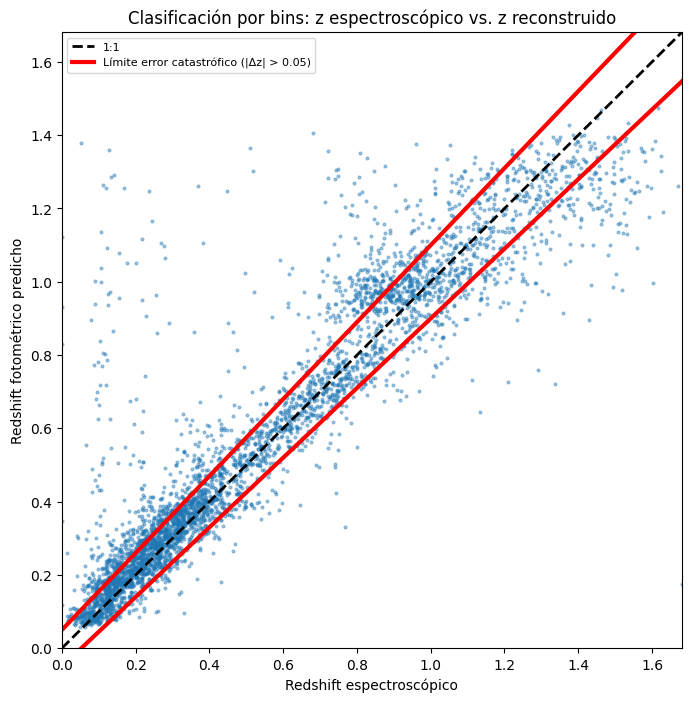

In [28]:
plot_specz_vs_photoz(
    z_test.to_numpy(), z_phot,
    threshold=0.05,
    title="Clasificación por bins: z espectroscópico vs. z reconstruido"
)
plt.show()

In [29]:
X.columns

Index(['type', 'shape_r', 'shape_e1', 'shape_e2', 'sersic', 'mag_g_corr',
       'mag_r_corr', 'mag_i_corr', 'mag_z_corr', 'mag_w1_corr', 'mag_w2_corr',
       'mag_w3_corr', 'mag_w4_corr'],
      dtype='str')

In [30]:
# Considerando el problema como regresión

X = X.copy()
y = df["z"].copy()

numeric_features = [c for c in X.columns if c != "type"]
categorical_features = ["type"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), categorical_features),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=124
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", HistGradientBoostingRegressor(
        random_state=42,
        learning_rate=0.05,
        max_depth=10,
        max_iter=300
    ))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")

# Residuos normalizados, σ_MAD y η
reg_metrics_v1 = compute_photoz_metrics(y_test.to_numpy(), y_pred, label="Regresión (sin colores)")

MAE:  0.0837
RMSE: 0.1480
R2:   0.8596
--- Métricas photo-z: Regresión (sin colores) ---
<Δz> (bias)              = 0.00766
std(Δz)                  = 0.09828
σ_MAD                    = 0.04682
η [%] (|Δz| > 0.05)     = 32.222


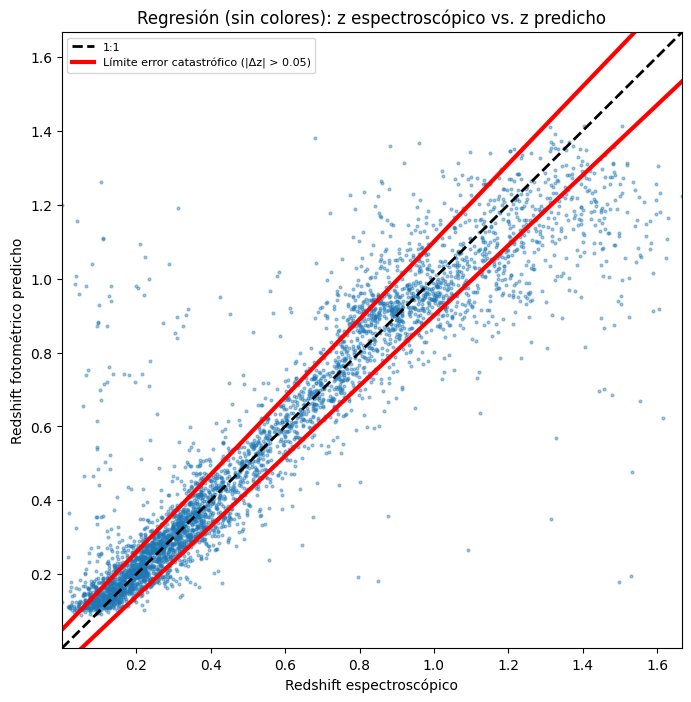

In [31]:
plot_specz_vs_photoz(
    y_test.to_numpy(), y_pred,
    threshold=0.05,
    title="Regresión (sin colores): z espectroscópico vs. z predicho"
)
plt.show()

Feature Engineering: añadir colores

In [32]:
# Colores a partir de magnitudes corregidas
color_pairs = [
    ("g", "i"),
    ("g", "r"),
    ("r", "i"),
    ("i", "z"),
    ("z", "w1"),
    ("w1", "w2"),
    ("w2", "w3"),
    ("w3", "w4"),
]

for b1, b2 in color_pairs:
    X[f"color_{b1}{b2}"] = X[f"mag_{b1}_corr"] - X[f"mag_{b2}_corr"]


In [33]:
X

,type,shape_r,shape_e1,shape_e2,sersic,mag_g_corr,mag_r_corr,mag_i_corr,mag_z_corr,mag_w1_corr,...,mag_w3_corr,mag_w4_corr,color_gi,color_gr,color_ri,color_iz,color_zw1,color_w1w2,color_w2w3,color_w3w4
0,REX,1.202857,0.000000,0.000000,1.000000,22.155801,21.371838,20.446027,19.990431,33.884193,...,78.409294,-2506.586850,1.709774,0.783963,0.925811,0.455596,-13.893762,14.206465,-58.731565,2584.996144
2,REX,0.305442,0.000000,0.000000,1.000000,23.097115,22.751573,22.477008,21.973593,-0.261648,...,19.844195,234.524798,0.620108,0.345543,0.274565,0.503414,22.235241,-1.327548,-18.778295,-214.680603
3,SER,0.509001,-0.049165,0.140539,4.798375,19.858807,19.101607,18.800058,18.611173,29.335098,...,83.687996,-1398.273356,1.058748,0.757199,0.301549,0.188885,-10.723925,11.212458,-65.565355,1481.961352
5,REX,0.259338,0.000000,0.000000,1.000000,23.334850,23.103095,22.598312,22.461767,0.649452,...,28.035550,-736.808516,0.736538,0.231755,0.504783,0.136545,21.812315,0.612276,-27.998374,764.844067
6,SER,0.840928,-0.024381,0.026650,5.345087,21.659299,19.783167,19.124658,18.784056,63.022541,...,178.876665,-4357.935789,2.534641,1.876131,0.658509,0.340602,-44.238484,20.209348,-136.063473,4536.812454
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29570,EXP,0.748664,0.079242,-0.310559,1.000000,22.770023,22.384707,22.228170,21.872057,0.715499,...,-33.086380,989.247252,0.541854,0.385317,0.156537,0.356113,21.156558,2.432220,31.369659,-1022.333632
29571,REX,0.830543,0.000000,0.000000,1.000000,22.620693,22.361899,21.933047,21.624911,2.375909,...,-77.835269,-10458.374229,0.687646,0.258793,0.428853,0.308136,19.249002,5.307935,74.903242,10380.538960
29572,REX,0.405263,0.000000,0.000000,1.000000,22.656275,22.414593,22.043448,21.861644,2.171333,...,74.195264,1033.254180,0.612828,0.241682,0.371145,0.181804,19.690311,4.207952,-76.231884,-959.058916
29573,SER,1.827961,-0.169518,-0.118707,0.915419,18.481759,18.020198,17.822375,17.691820,54.917491,...,165.980223,3588.497871,0.659384,0.461562,0.197823,0.130555,-37.225671,21.433900,-132.496632,-3422.517648


In [34]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), categorical_features),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_test_reg, y_test_reg = X_test, y_test  # se reutilizan más abajo para interpretabilidad

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", HistGradientBoostingRegressor(
        random_state=10,
        learning_rate=0.05,
        max_depth=6,
        max_iter=300
    ))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")

# Residuos normalizados, σ_MAD y η
reg_metrics_v2 = compute_photoz_metrics(y_test.to_numpy(), y_pred, label="Regresión (con colores)")

MAE:  0.0817
RMSE: 0.1486
R2:   0.8588
--- Métricas photo-z: Regresión (con colores) ---
<Δz> (bias)              = 0.00769
std(Δz)                  = 0.09579
σ_MAD                    = 0.04380
η [%] (|Δz| > 0.05)     = 30.554


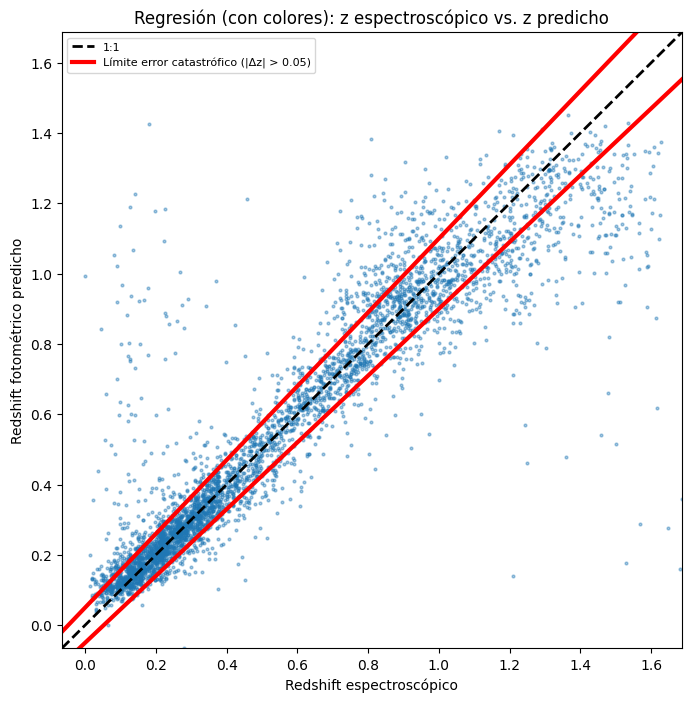

In [35]:
plot_specz_vs_photoz(
    y_test.to_numpy(), y_pred,
    threshold=0.05,
    title="Regresión (con colores): z espectroscópico vs. z predicho"
)
plt.show()

## Interpretabilidad de los modelos

Se calcula la **feature importance global** mediante *permutation importance*: se mide cuánto empeora el desempeño del modelo (evaluado en el set de test) al permutar aleatoriamente cada feature, rompiendo su relación con el target. Se aplica sobre el modelo de regresión final (con colores) y sobre el modelo de clasificación.

In [36]:
from sklearn.inspection import permutation_importance

# --- Regresión (modelo final, con colores) ---
perm_reg = permutation_importance(
    model, X_test_reg, y_test_reg,
    n_repeats=15,
    random_state=42,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
)

feature_names_reg = X_test_reg.columns.to_numpy()
importance_reg_df = pd.DataFrame({
    "feature": feature_names_reg,
    "importance_mean": perm_reg.importances_mean,
    "importance_std": perm_reg.importances_std,
}).sort_values("importance_mean", ascending=False)

print("Feature importance global — Regresión (permutation importance, ΔMAE):")
importance_reg_df

Feature importance global — Regresión (permutation importance, ΔMAE):


,feature,importance_mean,importance_std
6,mag_r_corr,0.389363,0.004825
5,mag_g_corr,0.134033,0.001877
7,mag_i_corr,0.067186,0.001104
9,mag_w1_corr,0.043055,0.001126
8,mag_z_corr,0.042033,0.001160
10,mag_w2_corr,0.014276,0.000530
1,shape_r,0.008391,0.000385
2,shape_e1,0.002799,0.000246
3,shape_e2,0.002770,0.000251
4,sersic,0.001154,0.000270


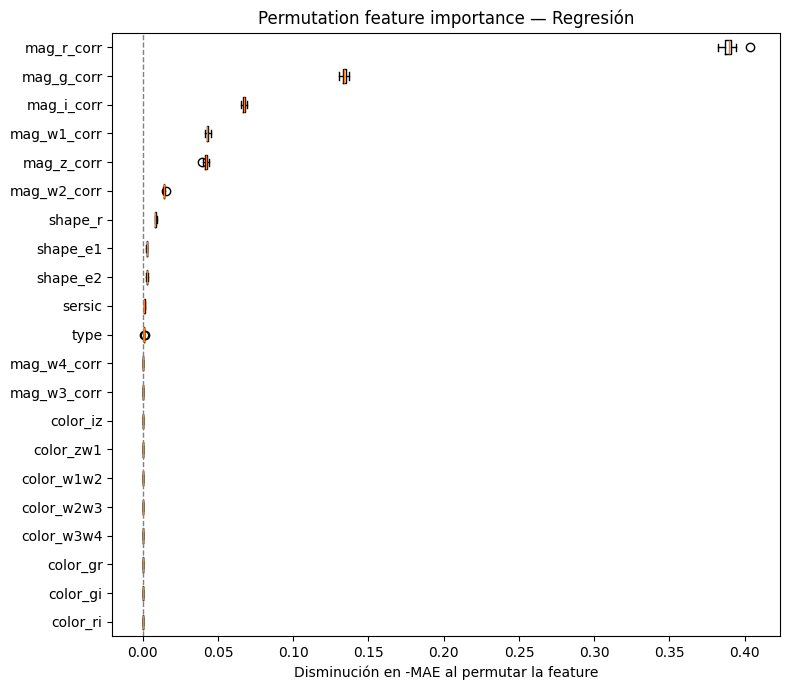

In [37]:
sorted_idx = perm_reg.importances_mean.argsort()

plt.figure(figsize=(8, 7))
plt.boxplot(
    perm_reg.importances[sorted_idx].T,
    vert=False,
    tick_labels=feature_names_reg[sorted_idx],
)
plt.axvline(0, color="grey", lw=1, ls="--")
plt.xlabel("Disminución en -MAE al permutar la feature")
plt.title("Permutation feature importance — Regresión")
plt.tight_layout()
plt.show()

In [38]:
# --- Clasificación ---
# scoring="balanced_accuracy" para que la importancia sea coherente con el manejo del desbalance de clases
perm_clf = permutation_importance(
    clf, X_test_clf, y_test_clf,
    n_repeats=15,
    random_state=42,
    scoring="balanced_accuracy",
    n_jobs=-1,
)

feature_names_clf = X_test_clf.columns.to_numpy()
importance_clf_df = pd.DataFrame({
    "feature": feature_names_clf,
    "importance_mean": perm_clf.importances_mean,
    "importance_std": perm_clf.importances_std,
}).sort_values("importance_mean", ascending=False)

print("Feature importance global — Clasificación (permutation importance, Δbalanced accuracy):")
importance_clf_df

Feature importance global — Clasificación (permutation importance, Δbalanced accuracy):


,feature,importance_mean,importance_std
6,mag_r_corr,0.218275,0.004854
5,mag_g_corr,0.196915,0.008426
7,mag_i_corr,0.145742,0.004631
9,mag_w1_corr,0.079882,0.006848
8,mag_z_corr,0.040262,0.004633
10,mag_w2_corr,0.036003,0.007228
1,shape_r,0.006924,0.005339
3,shape_e2,0.004217,0.003157
0,type,0.001337,0.001361
4,sersic,0.000757,0.002657


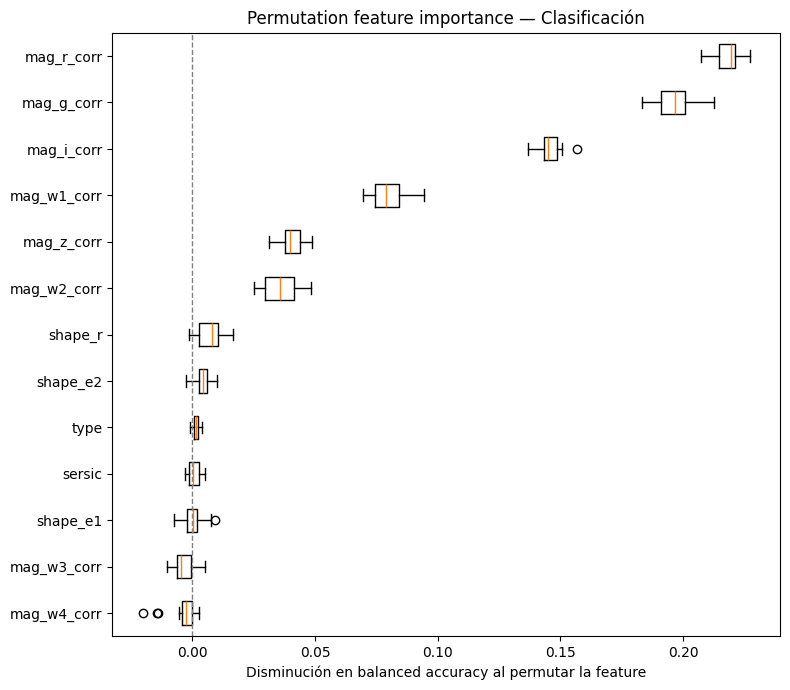

In [39]:
sorted_idx = perm_clf.importances_mean.argsort()

plt.figure(figsize=(8, 7))
plt.boxplot(
    perm_clf.importances[sorted_idx].T,
    vert=False,
    tick_labels=feature_names_clf[sorted_idx],
)
plt.axvline(0, color="grey", lw=1, ls="--")
plt.xlabel("Disminución en balanced accuracy al permutar la feature")
plt.title("Permutation feature importance — Clasificación")
plt.tight_layout()
plt.show()